# USDA Cat Detection List

Includes all cats (domestic and wild)

* Put together table of all cat outbreaks/detections recorded by USDA as of current date (6/3/2025)
* Cross reference date, state, and host to find genotype from our datasets

In [1]:
# Housekeeping

import os
import pandas as pd
import seaborn as sns
import matplotlib as plt
from matplotlib import pyplot
import dateutil 
from datetime import datetime, timedelta

home = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu/"
downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
cat_files = downloads + "Cats/"

os.chdir(home + "references/")
animals_ref = pd.read_csv("animals_ref.csv")
states_ref = pd.read_csv("states_ref.csv")

os.chdir(cat_files)
detections = pd.read_csv("HPAI Detections in Mammals.csv")


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu/references/'

In [ ]:
print(animals_ref["feline"])

display(detections)

0               cat
1      domestic_cat
2         feral_cat
3            feline
4      domestic-cat
           ...     
413             NaN
414             NaN
415             NaN
416             NaN
417             NaN
Name: feline, Length: 418, dtype: object


,State,County,Date Collected,Date Detected,HPAI Strain,Species
0,South Dakota,Aurora,5/6/2025,5/15/2025,EA H5,Domestic cat
1,Kansas,Kearny,1/30/2025,5/8/2025,EA H5,Bobcat
2,New York,Madison,4/23/2025,5/1/2025,EA H5,Red fox
3,New York,Onondaga,4/23/2025,5/1/2025,EA H5,Gray fox
4,Idaho,Ada,4/15/2025,4/29/2025,EA H5,Domestic cat
...,...,...,...,...,...,...
612,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
613,Wisconsin,Jefferson,4/9/2022,5/6/2022,EA H5N1,Red fox
614,Wisconsin,Dane,5/5/2022,5/6/2022,EA H5N1,Red fox
615,Wisconsin,Rock,4/19/2022,5/5/2022,EA H5N1,Red fox


In [ ]:
# Find only cats

detections["Species"] = detections["Species"].apply(str.lower)
detections["Feline"] = detections["Species"].apply(lambda x: "feline" if x in animals_ref["feline"].values else "non-feline")
detections_feline = detections[detections["Feline"] == "feline"]

print(detections_feline)

# Export as csv
detections_feline.to_csv("USDA_feline_detections_06_03_2025.csv")

detections_feline_unique = detections_feline.drop_duplicates(keep="last")
detections_feline_unique.to_csv("USDA_feline_detections_unique_06_03_2025.csv")

            State   County Date Collected Date Detected HPAI Strain  \
0    South Dakota   Aurora       5/6/2025     5/15/2025       EA H5   
1          Kansas   Kearny      1/30/2025      5/8/2025       EA H5   
4           Idaho      Ada      4/15/2025     4/29/2025       EA H5   
13       Colorado     Weld       4/4/2025     4/15/2025       EA H5   
20     California  Alameda     12/30/2024      4/4/2025       EA H5   
..            ...      ...            ...           ...         ...   
499      Nebraska  Madison      1/10/2023     1/13/2023     EA H5N1   
501        Oregon     Linn     12/27/2022      1/3/2023  EA/AM H5N1   
505        Oregon     Linn     12/19/2022    12/23/2022  EA/AM H5N1   
586     Wisconsin  Lincoln      4/24/2022     5/24/2022     EA H5N1   
587     Wisconsin  Lincoln       5/5/2022     5/24/2022     EA H5N1   

          Species  Feline  
0    domestic cat  feline  
1          bobcat  feline  
4    domestic cat  feline  
13   domestic cat  feline  
20   do

DatetimeIndex(['2022-04-30', '2022-07-31', '2022-10-31', '2023-01-31',
               '2023-04-30', '2023-07-31', '2023-10-31', '2024-01-31',
               '2024-04-30', '2024-07-31', '2024-10-31', '2025-01-31',
               '2025-04-30'],
              dtype='datetime64[ns]', name='date', freq='3ME')


C:\Users\maksi\AppData\Local\Temp\ipykernel_20876\701134973.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Date Collected"] = pd.to_datetime(detections_feline["Date Collected"].apply(dateutil.parser.parse), format="%Y-%m-%d") # .apply(lambda x: dateutil.parser.parse(x).strftime("%Y-%m-%d"))
C:\Users\maksi\AppData\Local\Temp\ipykernel_20876\701134973.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index = pd.date_range(start=detections_feline["Date Collected"].min(), end=detections_feline["Date Collected"].max(), freq="3M", name="date")


<Axes: xlabel='Date Collected', ylabel='Feline'>

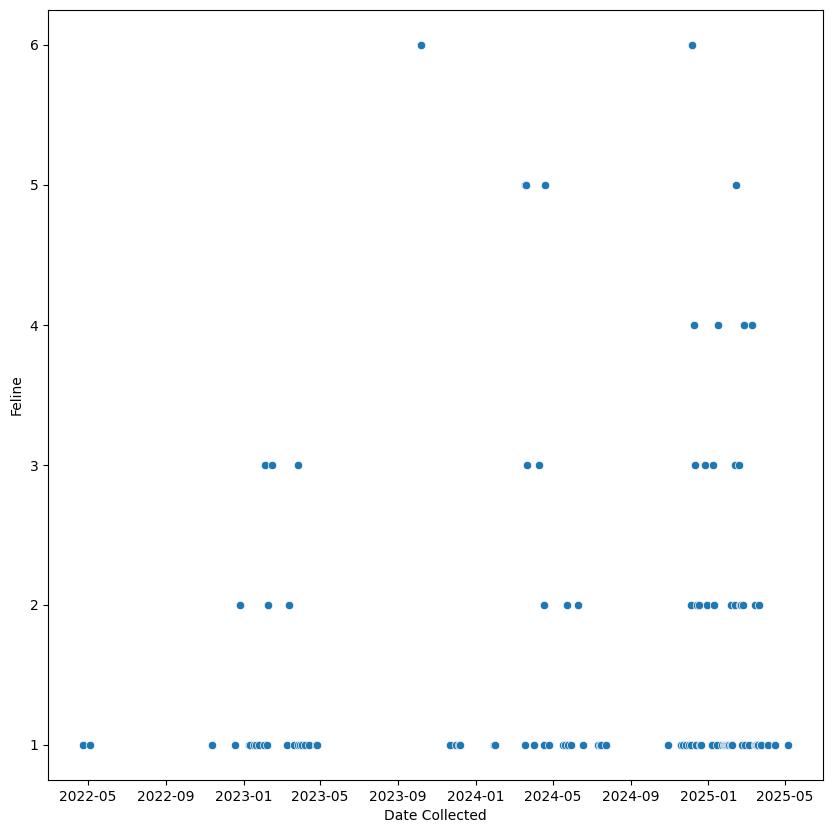

In [ ]:
# # Plot detections through time -- group by month/week 

# detections_feline["Date Collected"] = pd.to_datetime(detections_feline["Date Collected"].apply(dateutil.parser.parse), format="%Y-%m-%d") # .apply(lambda x: dateutil.parser.parse(x).strftime("%Y-%m-%d"))
# detections_feline_count = detections_feline.groupby("Date Collected").count().sort_index(ascending=True)

# # print(detections_feline_count)

# fig, ax = pyplot.subplots(1, 1, figsize=(10, 10))

# index = pd.date_range(start=detections_feline["Date Collected"].min(), end=detections_feline["Date Collected"].max(), freq="3M", name="date")
# # data = np.random.randn(100, 4).cumsum(axis=0)
# # wide_df = pd.DataFrame(data, index, ["a", "b", "c", "d"])
# print(index)

# # index_str = []
# # for x in list(index):
# #     index_str.append(str(x).replace("-", "/"))

# # diff = (pd.to_datetime(index, format='%Y-%m-%d') - pd.to_datetime('1990-1-1', format='%Y-%m-%d')).total_seconds()
# # s = pd.to_timedelta(pd.to_datetime(detections_feline["Date Collected"]).dt.time.astype(str))
# # detections_feline_count['time'] = pd.cut(s, bins=pd.to_timedelta(diff))

# sns.scatterplot(data = detections_feline_count, x=detections_feline_count.index, y=detections_feline_count["Feline"])
# # ax.set_xticks(range(len(list(index))))
# # ax.set_xticklabels(list(index), rotation=30)
# # break 
# # sns.scatterplot(data=wide_df)



## Find genotypes with feline from all_genotypes dataset 4-14-2025


In [ ]:
# Prepare dataframes 

os.chdir(downloads + "Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/")

def fasta_df(file_name, state_ref):

    fasta = pd.DataFrame()
    headers = []
    isolate_ids = []
    isolate_names = []
    subtypes = []
    segments = []
    collection_dates = []
    sequences = []
    host_types = []
    species = []
    genotypes = []
    with open(file_name) as f:
        lines = f.readlines()
        for num, line in enumerate(lines):
            # print(line)
            if line[0] == ">": # If it's a header
                if line[1:].strip() not in headers: # And the previous line is not a header we've seen before
                    header = line[1:].strip() # Remove the ">"
                    # print(header)
                    split_header = header.split("|")
                    split_first_header = split_header[0].split("/")
                    # print(split_header)
                    headers.append(header) 
                    isolate_ids.append(split_first_header[3])
                    isolate_names.append(split_header[0]) # We'll need to extract data from this too
                    # print(split_header[2].split("_")[-1])
                    subtypes.append(split_header[1])  # Get only H5N1
                    genotypes.append(split_header[-1])
                    segments.append(file_name.split("_")[-3])
                    host_types.append(split_header[3])
                    species.append(split_first_header[1])
                    # if split_header[4] == "2024-01-01":
                    #     collection_dates.append("2024") # No samples were collected 1/1/2024, these are all unknown 
                    # elif split_header[4] == "2025-01-01":
                    #     collection_dates.append("2025")
                    # else: 
                    collection_dates.append(split_header[2].split("_")[-1])
                    if num < len(lines): # If we're not at the last line
                        # for i, l in enumerate(lines[num + 1:]):
                        i = num
                        sequence = ""
                        # print(lines[i])
                        # print(lines[i + 1])
                        while i < len(lines) - 1 and lines[i + 1][0] != ">": # While the next line is part of a sequence
                            sequence = sequence + lines[i + 1].strip()
                            i += 1
                        sequences.append(sequence) # Add next line to sequences
        f.close()

    # Create columns for data frame 
    fasta["Header"] = headers
    fasta["Isolate_Id"] = isolate_ids
    fasta["Isolate_Name"] = isolate_names
    fasta["Subtype"] = subtypes
    fasta["Segment"] = segments
    # Geo_Location is more complicated
    fasta["Geo_Location"] = fasta["Header"].apply(lambda x: state_ref.loc[state_ref["Abbreviation"] == x.split("/")[2], 'Country'].iloc[0] + "-" + x.split("/")[2] if x.split("/")[2] in state_ref["Abbreviation"].values else state_ref.loc[state_ref["State"] == x.split("/")[2].replace("_", " "), 'Country'].iloc[0] + "-" + state_ref.loc[state_ref["State"] == x.split("/")[2].replace("_", " "), 'Abbreviation'].iloc[0] if x.split("/")[2].replace("_", " ") in state_ref["State"].values else x.split("/")[2].replace(": ", "-"))
    fasta["Date Collected"] = collection_dates
    fasta["Species"] = species
    fasta["Host_Type"] = host_types
    fasta["Genotype"] = genotypes
    fasta["Sequence"] = sequences
    
    return fasta

# Grab files
cat_genotypes = set()
dfs = {}
for dirpath, dirs, files in os.walk(downloads + "Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/"):
    for file in files:
        file_name = os.path.join(dirpath, file)
        # print(file_name)
        with open(file_name) as f:
            lines = f.readlines()
            for line in lines:
                if "feline" in line:
                    print(file_name)
                    cat_genotypes.add(line.split("|")[-1]) # The genotype
                    dfs[file_name] = fasta_df(file_name, states_ref)
                    break 

print(cat_genotypes)

C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\A3_HA_combined_04-14-2025.fasta
C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\A3_MP_combined_04-14-2025.fasta
C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\A3_NA_combined_04-14-2025.fasta
C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\A3_NP_combined_04-14-2025.fasta
C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotyp

### Cross-reference USDA cat list with our dataset to find genotypes

Append genotypes to USDA cat list

In [ ]:
# print(dfs["C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\D1.1_PB2_combined_04-14-2025.fasta"])

# Get cats only
cat_dfs = {}
for key in dfs.keys():
    df_value = dfs[key]
    cat_df = df_value[df_value["Host_Type"] == "feline"]
    cat_dfs[key] = cat_df

print(cat_dfs["C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\B3.13_PB2_combined_04-14-2025.fasta"])


                                                 Header     Isolate_Id  \
31    A/tiger/Idaho/24-035868-001/2024|H5N1|2024-11-...  24-035868-001   
59    A/cat/South_Dakota/038917-001/2024|H5N1|2024-1...     038917-001   
112   A/bobcat/Kansas/038225-002/2024|H5N1|2024-12-1...     038225-002   
177   A/bobcat/USA/004784-001/2025|H5N1|2025|feline|...     004784-001   
178   A/bobcat/USA/004784-002/2025|H5N1|2025|feline|...     004784-002   
268   A/cougar/USA/004744-002/2025|H5N1|2025|feline|...     004744-002   
270   A/cougar/USA/004744-001/2025|H5N1|2025|feline|...     004744-001   
366   A/cat/South_Dakota/003786-001/2025|H5N1|2025-0...     003786-001   
405   A/cat/Minnesota/24-037542-001/2024|H5N1|2024-1...  24-037542-001   
594   A/cat/South_Dakota/000089-001/2024|H5N1|2024-1...     000089-001   
654     A/cat/USA/002248-002/2025|H5N1|2025|feline|D1.1     002248-002   
846   A/cat/Kansas/001092-001/2024|H5N1|2024-12-31|f...     001092-001   
855   A/Cat/AB/FAV-0015-1/2025|H5N1|20

In [ ]:
# Get same geolocation for detections_feline

detections_feline["Geo_Location"] = detections_feline["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)

print(detections_feline)


detections_feline_unique["Geo_Location"] = detections_feline_unique["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)

print(detections_feline_unique)

            State   County Date Collected Date Detected HPAI Strain  \
0    South Dakota   Aurora       5/6/2025     5/15/2025       EA H5   
1          Kansas   Kearny      1/30/2025      5/8/2025       EA H5   
4           Idaho      Ada      4/15/2025     4/29/2025       EA H5   
13       Colorado     Weld       4/4/2025     4/15/2025       EA H5   
20     California  Alameda     12/30/2024      4/4/2025       EA H5   
..            ...      ...            ...           ...         ...   
499      Nebraska  Madison      1/10/2023     1/13/2023     EA H5N1   
501        Oregon     Linn     12/27/2022      1/3/2023  EA/AM H5N1   
505        Oregon     Linn     12/19/2022    12/23/2022  EA/AM H5N1   
586     Wisconsin  Lincoln      4/24/2022     5/24/2022     EA H5N1   
587     Wisconsin  Lincoln       5/5/2022     5/24/2022     EA H5N1   

          Species  Feline Geo_Location  
0    domestic cat  feline       USA-SD  
1          bobcat  feline       USA-KS  
4    domestic cat  felin

C:\Users\maksi\AppData\Local\Temp\ipykernel_25000\2494737573.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  detections_feline["Geo_Location"] = detections_feline["State"].apply(lambda x: states_ref.loc[states_ref["Abbreviation"] == x, 'Country'].iloc[0] + "-" + x if x in states_ref["Abbreviation"].values else states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Country'].iloc[0] + "-" + states_ref.loc[states_ref["State"] == x.replace("_", " "), 'Abbreviation'].iloc[0] if x.replace("_", " ") in states_ref["State"].values else x)
C:\Users\maksi\AppData\Local\Temp\ipykernel_25000\2494737573.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

### If geo_location and species match, add list of possible genotypes to USDA


In [ ]:
# Find genotypes matching USDA

matches = {}
for key in cat_dfs.keys():
    df = cat_dfs[key]
    # concat_df = pd.concat([detections_feline, df], ignore_index=True) # concatenate the dfs
    # no_dupes_df = concat_df.drop_duplicates(subset=["State", "Date Collected", "Species"])
    combined_df = pd.merge(detections_feline_unique, df, on=["Geo_Location"])
    matches[key] = combined_df
    # print(combined_df)

matches_exist = {}
for key in matches.keys():
    # If dataframe not empty, show it 
    if len(matches[key]) > 0:
        matches_exist[key] = matches[key]
        # print(matches[key])

print(matches_exist)


{'C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/Combinations/GISAID_Andersen/11-01-2021--04-14-2025_all_genotypes-20250604T192435Z-1-001/11-01-2021--04-14-2025_all_genotypes\\A3_HA_combined_04-14-2025.fasta':        State      County Date Collected_x Date Detected HPAI Strain  \
0  Minnesota  Cottonwood        12/9/2024      1/2/2025  EA/AM H5N1   
1  Minnesota    Morrison        12/6/2024    12/18/2024     EA H5N1   
2  Minnesota      Sibley        6/10/2024     6/27/2024     EA H5N1   
3  Minnesota      Sibley        6/10/2024     6/27/2024       EA H5   
4  Minnesota   Kandiyohi        6/18/2024     6/21/2024     EA H5N1   

      Species_x  Feline Geo_Location  \
0  domestic cat  feline       USA-MN   
1  domestic cat  feline       USA-MN   
2  domestic cat  feline       USA-MN   
3  domestic cat  feline       USA-MN   
4  domestic cat  feline       USA-MN   

                                              Header     Isolate_Id  \
0  A/cat/Minnesota/24-036601-001/2024

In [ ]:
# Make list of possible genotypes per USDA row 

# Concatenate all matches_exist dataframes and drop duplicates on the columns

big_df = pd.DataFrame()
for key in matches_exist.keys():
    df = matches[key]
    big_df = pd.concat([big_df, df], ignore_index=True)



# big_df_dupes = big_df[big_df.duplicated(subset=["Geo_Location", "Species", "Genotype"], keep=False)]

# print(big_df)

# big_df_no_seg = big_df.drop(columns=["Segment", "Sequence"])

big_df = big_df.drop_duplicates(subset=["Isolate_Id", "Genotype"], keep="last", ignore_index=True)

big_df["Date Collected_x"] = big_df["Date Collected_x"].apply(lambda x: dateutil.parser.parse(x)) #.strftime("%Y-%m-%d"))
big_df["Date Detected"] = big_df["Date Detected"].apply(lambda x: dateutil.parser.parse(x)) #.strftime("%Y-%m-%d"))
big_df["Date Collected_y"] = big_df["Date Collected_y"].apply(lambda x: dateutil.parser.parse(x)) #.strftime("%Y-%m-%d"))

print(big_df)

# subset=["Date Collected_x", "Geo_Location", "Species", "Genotype"]
# big_df = big_df.drop_duplicates(subset=["Isolate_Id", "Genotype"], keep='last', ignore_index=True)

# print(big_df_dupes)

# print(big_df)

           State     County Date Collected_x Date Detected HPAI Strain  \
0      Minnesota  Kandiyohi       2024-06-18    2024-06-21     EA H5N1   
1      Minnesota  Kandiyohi       2024-06-18    2024-06-21     EA H5N1   
2      Minnesota  Kandiyohi       2024-06-18    2024-06-21     EA H5N1   
3          Idaho     Jerome       2024-05-23    2024-06-03     EA H5N1   
4       Michigan   Isabella       2024-04-19    2024-04-24     EA H5N1   
..           ...        ...              ...           ...         ...   
86  South Dakota    Jerauld       2023-10-07    2023-11-14     EA H5N1   
87  South Dakota    Jerauld       2023-10-07    2023-11-14     EA H5N1   
88  South Dakota    Jerauld       2023-10-07    2023-11-14     EA H5N1   
89  South Dakota    Jerauld       2023-10-07    2023-11-14     EA H5N1   
90  South Dakota    Jerauld       2023-10-07    2023-11-14     EA H5N1   

       Species_x  Feline Geo_Location  \
0   domestic cat  feline       USA-MN   
1   domestic cat  feline     

In [ ]:
# Make sure dates correspond by checking if:
# Date Collected_y is between Date Collected_x and Date Detected
# OR 
# Date Collected_y, if year only, corresponds to either Date Collected_x year or Date Detected year

big_df["Date_Match_Beg"] = big_df["Date Collected_y"] - big_df["Date Collected_x"]
big_df["Date_Match_Beg"] = big_df["Date_Match_Beg"].apply(lambda x: 1 if x >= timedelta(days = 0) else 0)

big_df["Date_Match_End"] = big_df["Date Detected"] - big_df["Date Collected_y"]
big_df["Date_Match_End"] = big_df["Date_Match_End"].apply(lambda x: 1 if x >= timedelta(days = 0) else 0)

big_df["Date_Match_Sum"] = big_df["Date_Match_Beg"] + big_df["Date_Match_End"]

big_df = big_df[big_df["Date_Match_Sum"] > 1]

print(big_df)

         State    County Date Collected_x Date Detected HPAI Strain  \
3        Idaho    Jerome       2024-05-23    2024-06-03     EA H5N1   
4     Michigan  Isabella       2024-04-19    2024-04-24     EA H5N1   
5     Michigan  Isabella       2024-04-19    2024-04-24     EA H5N1   
6     Michigan  Isabella       2024-04-19    2024-04-24     EA H5N1   
12    Michigan  Isabella       2024-04-19    2024-04-24     EA H5N1   
13    Oklahoma    Harmon       2024-03-20    2024-04-17  EA/AM H5N1   
14  New Mexico     Curry       2024-03-20    2024-04-01  EA/AM H5N1   
15  New Mexico     Curry       2024-03-20    2024-04-01  EA/AM H5N1   
16  New Mexico     Curry       2024-03-20    2024-04-01  EA/AM H5N1   
21       Texas      Hale       2024-03-22    2024-03-25  EA/AM H5N1   
22       Texas      Hale       2024-03-22    2024-03-25  EA/AM H5N1   
76   Wisconsin   Lincoln       2022-05-05    2022-05-24     EA H5N1   

       Species_x  Feline Geo_Location  \
3   domestic cat  feline       USA-

In [ ]:
os.chdir(cat_files)

# big_df.to_csv("Possible_Genotypes_USDA_Feline_Unique_Isolates.csv", index=None)

big_df.to_csv("Possible_Genotypes_USDA_Feline.csv", index=None)